In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from scipy.stats import fisher_exact
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

In [2]:
mutdelsnorm_path = "data/mut_deletion_lengths.tsv"
pancan_path = 'data/pancan_twohitfreq.tsv'
roles_path = "data/generoles.tsv"
tcga_path = "data/tcga_mut_somaticgermline.tsv"
genes_path = "data/gene-coordinates_hg19.tsv"
bands_path = "data/genes_chromosome-bands_msigdb.tsv"

In [3]:
mutdelsnorm = pd.read_csv(mutdelsnorm_path, sep='\t')
pancan = pd.read_csv(pancan_path, sep='\t')
roles = pd.read_csv(roles_path, sep = '\t')
tcga = pd.read_csv(tcga_path, sep = '\t')
genes = pd.read_csv(genes_path, sep = '\t')
bands = pd.read_csv(bands_path, sep = '\t')

/home/sabari/niveditam/miniconda3/envs/equinox_minimal/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3508: DtypeWarning: Columns (21,24,26) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)
/home/sabari/niveditam/miniconda3/envs/equinox_minimal/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3508: DtypeWarning: Columns (12) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [4]:
def config_rcparams():
    plt.rcParams['font.family'] = ['sans-serif']
    plt.rcParams['font.sans-serif'] = ['arial']
    plt.rcParams['svg.fonttype'] = 'none' 
    plt.rcParams['mathtext.fontset'] = 'custom'
    plt.rcParams['mathtext.cal'] = 'arial'
    plt.rcParams['mathtext.rm'] = 'arial'
    plt.rcParams['axes.linewidth'] = 0.7
    plt.rcParams['xtick.major.width'] = 0.7
    plt.rcParams['ytick.major.width'] = 0.7
    plt.rcParams['xtick.major.size'] = 3
    plt.rcParams['ytick.major.size'] = 3

---

# Fig 3A

In [5]:
# preparing dataset

mutdelsnorm['chrom'] = mutdelsnorm['chrom'].astype('str')
mutdelsnorm = mutdelsnorm[~mutdelsnorm['chrom'].isin(['X','Y'])] # removing sex chromosomes
print(len(mutdelsnorm))

tcgazf = tcga[(tcga['Variant_Classification']!='Silent')&(tcga['midan_filter']=='keep')].copy()
mutdelsnorm_nosil = mutdelsnorm[mutdelsnorm['Variant_Classification']!='Silent'].copy()

zf = tcgazf[['Hugo_Symbol','tissue','Chromosome','Start_Position','End_Position','Variant_Type']].rename(columns={'Chromosome':'chrom'})
zf['zf'] = 'keep'

mutdelsnorm_zf = pd.merge(mutdelsnorm_nosil,zf,on=['Hugo_Symbol','tissue','chrom','Start_Position','End_Position','Variant_Type'],how='left')
print(len(mutdelsnorm))
print(len(mutdelsnorm_zf))

mutdelsnorm_zf = mutdelsnorm_zf[mutdelsnorm_zf.zf=='keep']
print(len(mutdelsnorm_zf))

tsgs = roles[roles['role']=='TSG'].Hugo_Symbol.unique()
mutdelsnorm_zf_tsg = mutdelsnorm_zf[mutdelsnorm_zf.Hugo_Symbol.isin(tsgs)]

162440
162440
122083
73654


findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial
/tmp/ipykernel_3718/3102067664.py:76: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial


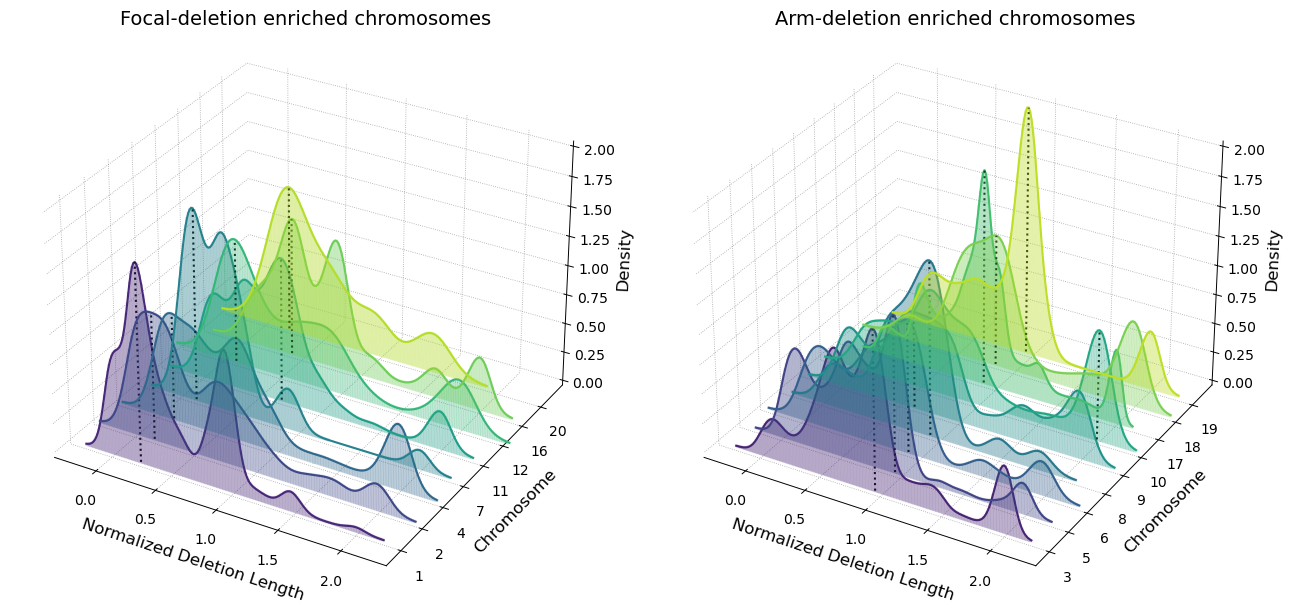

In [6]:
config_rcparams()

# Preparing dataframe

mini = ['tissue','chrom','del_start','del_end']
df1 = mutdelsnorm_zf_tsg[mini+['del_length_normalised']].drop_duplicates()[['chrom','del_length_normalised']]

# Split the DataFrame and define chromosome orders
df1a = df1[df1.chrom.isin(['1', '2', '4', '7', '11', '12', '16', '20'])]
chrom_ordera = ['1', '2', '4', '7', '11', '12', '16', '20']

df1b = df1[~df1.chrom.isin(['1', '2', '4', '7', '11', '12', '16', '20'])]
chrom_orderb = ['3', '5', '6', '8', '9', '10', '17', '18', '19']

# Plotting

# Create the figure and two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 8), subplot_kw={"projection": "3d"})
fig.subplots_adjust(wspace=0.1)

# Function to plot 3D KDEs
def plot_kde_3d(ax, df_subset, chrom_order, title):
    ax.set_facecolor('white')
    ax.w_xaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
    ax.w_yaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
    ax.w_zaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
    
    ax.grid(True)
    for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
        axis._axinfo["grid"]["linestyle"] = ":"
        axis._axinfo["grid"]["linewidth"] = 0.6
        axis._axinfo["grid"]["color"] = (0.5, 0.5, 0.5, 0.7) 

    colors = sns.color_palette("viridis", len(chrom_order))

    for i, chrom_value in enumerate(chrom_order):
        filtered_data = df_subset[df_subset['chrom'] == chrom_value]['del_length_normalised']
        
        # Generate density plot using seaborn
        temp_fig = plt.figure()
        kde = sns.kdeplot(filtered_data, bw_adjust=0.5)
        x = kde.get_lines()[0].get_xdata()
        y = kde.get_lines()[0].get_ydata()
        plt.close(temp_fig)  # Close temp figure

        z = np.full_like(x, i)
        ax.plot(x, z, y, label=chrom_value, color=colors[i], linestyle='-')
        
        # Drop perpendicular from peak to XY plane
        peak_idx = np.argmax(y)
        peak_x = x[peak_idx]
        peak_y = y[peak_idx]
        peak_z = i
        ax.plot([peak_x, peak_x], [peak_z, peak_z], [0, peak_y], color='black', linestyle=':', linewidth=1.5)

        for j in range(len(x) - 1):
            ax.plot([x[j], x[j]], [z[j], z[j]], [0, y[j]], color=colors[i], alpha=0.12, lw=2)
            ax.plot([x[j + 1], x[j + 1]], [z[j + 1], z[j + 1]], [0, y[j + 1]], color=colors[i], alpha=0.12, lw=2)

    ax.set_xlabel('Normalized Deletion Length', fontsize=12)
    ax.set_ylabel('Chromosome', fontsize=12)
    ax.set_zlabel('Density', fontsize=12)
    ax.set_yticks(range(len(chrom_order)))
    ax.set_yticklabels(chrom_order)
    ax.set_xlim(-0.3,2.3)
    ax.set_zlim(0, 2)
    ax.set_ylim(-0.5, len(chrom_order))
    ax.set_title(title, fontsize=14, y=1.05)

# Plot first subplot (A chromosomes)
plot_kde_3d(axes[0], df1a, chrom_ordera, title='Focal-deletion enriched chromosomes')

# Plot second subplot (B chromosomes)
plot_kde_3d(axes[1], df1b, chrom_orderb, title='Arm-deletion enriched chromosomes')

plt.tight_layout()

plt.show()

---

# Fig S5A

22
22


Text(153.75, 0.5, 'Deletion type')

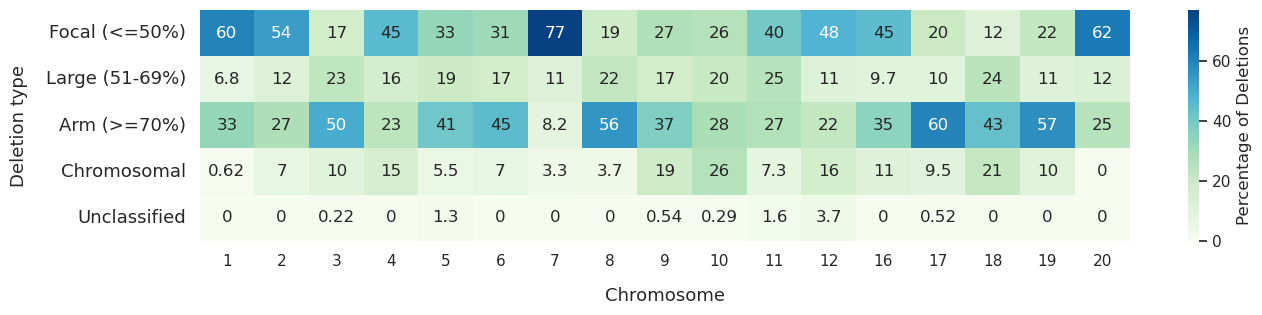

In [7]:
config_rcparams()

# deletions co-occurring with mutations in TSGs

plt.figure(figsize=(15,3))

muto = mutdelsnorm_zf_tsg[mutdelsnorm_zf_tsg['del_arm']!='both'].drop_duplicates(subset=mini)[['tissue','chrom','deltype']]
mutb = mutdelsnorm_zf_tsg[mutdelsnorm_zf_tsg['del_arm']=='both'].drop_duplicates(subset=mini)[['tissue','chrom','deltype_sa']]#.replace({'nan':np.nan}).dropna()
mutb.columns = ['tissue','chrom','deltype']
mut_tsg = pd.concat([muto,mutb])
mut_tsg = mut_tsg.groupby(['chrom'])['deltype'].value_counts().to_frame().rename(columns={'deltype':'counts'}).reset_index().pivot(index=['chrom'],columns='deltype', values='counts').reset_index().fillna(0)
mut_tsg['tot'] = mut_tsg['arm'] + mut_tsg['focal'] + mut_tsg['large'] + mut_tsg['unclassified'] + mut_tsg['chr']
print(len(mut_tsg))
#mut_tsg = mut_tsg[mut_tsg['tot']>=10]
print(len(mut_tsg))
mut_tsg['arm%'] = 100*mut_tsg['arm']/mut_tsg['tot']
mut_tsg['focal%'] = 100*mut_tsg['focal']/mut_tsg['tot']
mut_tsg['chr%'] = 100*mut_tsg['chr']/mut_tsg['tot']
mut_tsg['unclassified%'] = 100*mut_tsg['unclassified']/mut_tsg['tot']
mut_tsg['large%'] = 100*mut_tsg['large']/mut_tsg['tot']
#mut_tsg['arm'] = mut_tsg['del_arm'].apply(lambda x:x[-1:])'''
mut_tsg = mut_tsg[['chrom','focal%','large%','arm%','chr%','unclassified%']].set_index('chrom')
mut_tsg = mut_tsg.transpose()[['1','2','3','4','5','6','7','8','9','10','11','12','16','17','18','19','20']]

sns.set_theme(rc={'figure.figsize':(10,2)})
sns.set_style('white')

ax = sns.heatmap(mut_tsg, cmap='GnBu',annot=True,cbar_kws={'label': 'Percentage of Deletions'})

ax.set_yticklabels(['Focal (<=50%)','Large (51-69%)','Arm (>=70%)','Chromosomal','Unclassified'], fontsize=13)
#ax.set_yticklabels(['Focal \n(NDL<=0.5)','Large \n(NDL 0.51-0.69)','Arm \n(NDL>=0.7)','Chromosomal','Others'], fontsize=13)
ax.set_xlabel('Chromosome', fontsize=13, labelpad=13)
ax.set_ylabel('Deletion type', fontsize=13, labelpad=13)

/tmp/ipykernel_3718/3491326612.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial


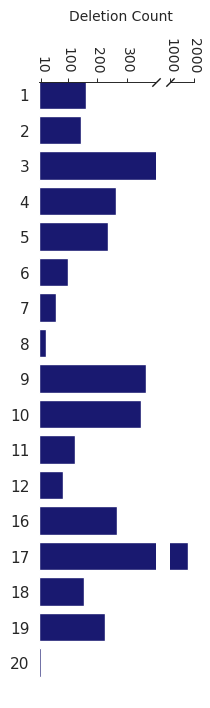

In [8]:
config_rcparams()

# barplot for tot deletions

# Group and prepare data
muto = mutdelsnorm_zf_tsg[mutdelsnorm_zf_tsg['del_arm']!='both'].drop_duplicates(subset=mini)[['tissue','chrom','deltype']]
mutb = mutdelsnorm_zf_tsg[mutdelsnorm_zf_tsg['del_arm']=='both'].drop_duplicates(subset=mini)[['tissue','chrom','deltype_sa']]#.replace({'nan':np.nan}).dropna()
mutb.columns = ['tissue','chrom','deltype']
mut_tsg = pd.concat([muto,mutb])
mut_tsg = mut_tsg.groupby(['chrom'])['deltype'].value_counts().to_frame().rename(columns={'deltype':'counts'}).reset_index().pivot(index=['chrom'],columns='deltype', values='counts').reset_index().fillna(0)
mut_tsg['tot'] = mut_tsg['arm'] + mut_tsg['focal'] + mut_tsg['large'] + mut_tsg['unclassified'] + mut_tsg['chr']
#mut_tsg = mut_tsg[mut_tsg['tot']>=10]

data_ = mut_tsg[~mut_tsg.chrom.isin(['13','14','15','21','22'])][['chrom','tot']]
data = []
for i in range(20,0,-1):
    data.append(data_[data_.chrom==str(i)])
data = pd.concat(data)

# Create broken axes
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(2,8), gridspec_kw={'width_ratios': [5, 1], 'hspace': 0.01})

# Define the break point
breakpoint = 400

# Plot left (low) part
ax1.barh(data['chrom'], data['tot'],color='midnightblue')
ax1.set_xlim(0, breakpoint)

# Plot right (high) part
ax2.barh(data['chrom'], data['tot'],color='midnightblue')
ax2.set_xlim(1000,3000)

# Hide spines between the axes
ax1.tick_params(labelright=False,labelbottom=True)
ax2.tick_params(labelleft=False,labelbottom=True)

# Add diagonal lines to indicate the break
d = .015  

# Arguments common to both
kwargs = dict(marker=[(-1, -1), (1, 1)], markersize=6,
              linestyle='none', color='k', mec='k', mew=1, clip_on=False)

# Plot diagonal lines manually (perfectly matched)
ax1.plot([1], [1], transform=ax1.transAxes, **kwargs)
ax2.plot([0], [1], transform=ax2.transAxes, **kwargs)

# Final layout
#fig.subplots_adjust(wspace=0.02)
ax1.set_xlabel('Deletion Count', labelpad=15, fontsize=10)
ax1.xaxis.set_label_position('top')
ax1.xaxis.set_label_coords(0.7, 1.1)
plt.tight_layout()

xtick_positions = [10, 100, 200, 300]
xtick_labels = ['10', '100', '200', '300']
ax1.set_xticks(xtick_positions)
ax1.set_xticklabels(xtick_labels, rotation=-90,fontsize=10)

xtick_positions = [1000, 3200]
xtick_labels = ['1000','2000']
ax2.set_xticks(xtick_positions)
ax2.set_xticklabels(xtick_labels, rotation=-90,fontsize=10)

ax1.set_ylim(-1,16.35)
ax2.set_ylim(-1,16.35)

ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.spines['right'].set_visible(False)

for ax in [ax1, ax2]:
    ax.xaxis.tick_top()                         # Move tick labels to top
    ax.tick_params(labeltop=True, labelbottom=False)  # Show top ticks, hide bottom ones
    ax.xaxis.set_label_position('top')          # Move axis label to top

plt.show()

---

# Fig 3B

Arm-deletion percentages (TSG two-hits)

In [9]:
# preparing dataset

muto = mutdelsnorm_zf_tsg[mutdelsnorm_zf_tsg['del_arm']!='both'].drop_duplicates(subset=mini)[['tissue','chrom','del_arm','del_length_normalised','deltype']]
mutb = mutdelsnorm_zf_tsg[mutdelsnorm_zf_tsg['del_arm']=='both'].drop_duplicates(subset=mini)[['tissue','chrom','del_sa_arm','del_sa_length_normalised','deltype_sa']].replace({'nan':np.nan}).dropna()
mutb.columns = ['tissue','chrom','del_arm','del_length_normalised','deltype']
mut_tsg = pd.concat([muto,mutb])
mut_tsg = mut_tsg.groupby(['chrom','del_arm'])['deltype'].value_counts().to_frame().rename(columns={'deltype':'counts'}).reset_index().pivot(index=['chrom','del_arm'],columns='deltype', values='counts').reset_index().fillna(0)
mut_tsg['tot'] = mut_tsg['arm'] + mut_tsg['focal'] 
print(len(mut_tsg))
mut_tsg = mut_tsg[mut_tsg['tot']>=10]
print(len(mut_tsg))
mut_tsg['mutarm'] = 100*mut_tsg['arm']/mut_tsg['tot']
mut_tsg['arm'] = mut_tsg['del_arm'].apply(lambda x:x[-1:])

39
28


/home/sabari/niveditam/miniconda3/envs/equinox_minimal/lib/python3.8/site-packages/pandas/core/indexing.py:723: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  iloc._setitem_with_indexer(indexer, value, self.name)
/tmp/ipykernel_3718/3245694734.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['chrom'] = df['chrom'].astype(int)
/tmp/ipykernel_3718/3245694734.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pa

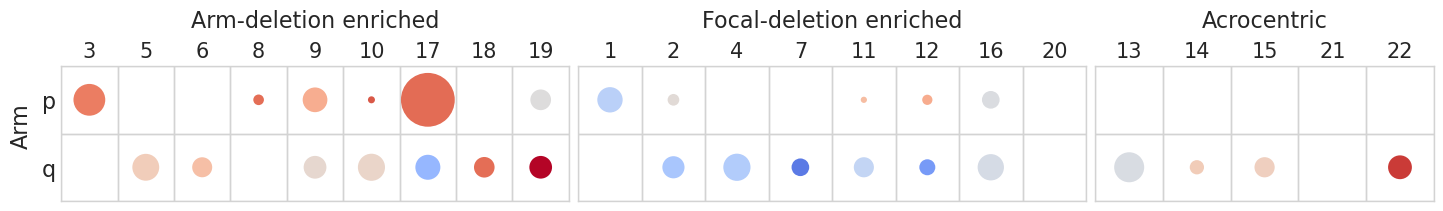

In [10]:
config_rcparams()

data = mut_tsg.copy()
df = []
for i in range(1, 23):
    df.append(data[data.chrom == str(i)])
df_ = pd.concat(df).reset_index(drop=True)

# Custom bubble size scaling
def size_scale(tot_values, min_size=20, max_size=1500):
    sqrt_vals = np.sqrt(tot_values)
    scaled = min_size + (sqrt_vals - sqrt_vals.min()) / (sqrt_vals.max() - sqrt_vals.min()) * (max_size - min_size)
    return scaled

df_['size'] = size_scale(df_['tot'])

# add missing chrom (missing due to low sample size)
df_before = df_.iloc[:1]
df_after = df_.iloc[1:]
df_before.loc[len(df_before)] = ['20','chr20p','p',0,0,0,0,0]
df_before.loc[len(df_before)] = ['21','chr21q','q',0,0,0,0,0]
df_ = pd.concat([df_before, df_after])

# Normalize hue
norm = plt.Normalize(df_['mutarm'].min(), df_['mutarm'].max())
cmap = plt.cm.coolwarm

# Grouped dataframes (left → right)
df1 = df_[df_.chrom.isin(['3','5','6','8','9','10','17','18','19'])]   # arm enriched
df2 = df_[df_.chrom.isin(['1','2','4','7','11','12','16','20'])]      # focal enriched
df3 = df_[df_.chrom.isin(['13','14','15','21','22'])]                 # acrocentric

dfs = [df1, df2, df3]
group_labels = ['Arm-deletion enriched', 'Focal-deletion enriched', 'Acrocentric']

# Create horizontal subplots
fig, axes = plt.subplots(
    nrows=1, ncols=3,
    figsize=(14, 2),
    sharey=True,
    gridspec_kw={'width_ratios': [len(df1.chrom.unique()),
                                  len(df2.chrom.unique()) + 1,
                                  len(df3.chrom.unique()) + 1]},
    constrained_layout=True
)

for i, (df, ax) in enumerate(zip(dfs, axes)):

    # Preserve chromosome order
    df['chrom'] = df['chrom'].astype(int)
    unique_chroms = sorted(df['chrom'].unique())
    chrom_to_x = {chrom: i for i, chrom in enumerate(unique_chroms)}
    df['x'] = df['chrom'].map(chrom_to_x)
    df['chrom'] = df['chrom'].astype(str)  # back to string for labeling
    
    # p on top, q on bottom
    df['y'] = df['arm'].map({'p': 1, 'q': 0})

    ax.set_facecolor('white')

    # Light grey spines
    for spine in ax.spines.values():
        spine.set_edgecolor('lightgrey')
        spine.set_linewidth(1)

    # Background grid
    for x in range(len(unique_chroms)):
        for y in [0, 1]:
            ax.add_patch(
                plt.Rectangle((x - 0.5, y - 0.5), 1, 1,
                              fill=False, edgecolor='lightgrey',
                              lw=1, zorder=0)
            )

    # Bubble plot
    ax.scatter(
        df['x'], df['y'],
        s=df['size'],
        c=df['mutarm'],
        cmap=cmap,
        norm=norm,
        edgecolor='none',
        alpha=1,
        zorder=2
    )

    # Axes formatting
    ax.set_xticks(range(len(unique_chroms)))
    ax.set_xticklabels(unique_chroms, fontsize=15)

    ax.set_yticks([1, 0])
    ax.set_yticklabels(['p', 'q'], fontsize=16)

    ax.set_xlim(-0.5, len(unique_chroms) - 0.5)
    ax.set_ylim(-0.5, 1.5)

    ax.tick_params(axis='y', length=0)
    
    ax.xaxis.set_ticks_position('top')
    ax.xaxis.set_label_position('top')
    ax.tick_params(axis='x', which='both',
                   top=True, bottom=False,
                   labeltop=True, labelbottom=False,
                   length=0)

    # Group title
    ax.set_title(group_labels[i], fontsize=16, pad=10)

# Shared labels
fig.supylabel('Arm', fontsize=16, x=-0.02, y=0.4)

plt.show()

---

# Fig S5B

In [11]:
# preparing dataset

muto = mutdelsnorm_zf_tsg[mutdelsnorm_zf_tsg['del_arm']!='both'].drop_duplicates(subset=mini)[['tissue','CODE','del_arm','del_length_normalised','deltype']]
mutb = mutdelsnorm_zf_tsg[mutdelsnorm_zf_tsg['del_arm']=='both'].drop_duplicates(subset=mini)[['tissue','CODE','del_sa_arm','del_sa_length_normalised','deltype_sa']].replace({'nan':np.nan}).dropna()
mutb.columns = ['tissue','CODE','del_arm','del_length_normalised','deltype']
mut_tsg = pd.concat([muto,mutb])
mut_tsg['arm'] = mut_tsg['del_arm'].apply(lambda x:x[3:])
mut_tsg_tumorcounts = mut_tsg.groupby('arm')['CODE'].value_counts().to_frame().rename(columns={'CODE':'count'}).reset_index().pivot(index='CODE',columns='arm',values='count').fillna(0)
mut_tsg_tumorcounts = mut_tsg_tumorcounts[list(mut_tsg.arm.value_counts().index)]

mut_tsg_tumorcounts = mut_tsg_tumorcounts[['1p','1q','2p','2q','3p','3q','4p','4q','5p','5q','6p','6q','7p','7q','8p','8q','9p','9q','10p','10q','11p','11q','12p','12q','13q','14q','15q','16p','16q','17p','17q','18p','18q','19p','19q','20p','20q','21q','22q']]
mut_tsg_tumorcounts = mut_tsg_tumorcounts.reset_index().melt(id_vars='CODE', value_vars = mut_tsg_tumorcounts.columns).rename(columns={'value':'tot'})

muto = mutdelsnorm_zf_tsg[mutdelsnorm_zf_tsg['del_arm']!='both'][['tissue','CODE','del_arm','del_length_normalised','deltype']]
mutb = mutdelsnorm_zf_tsg[mutdelsnorm_zf_tsg['del_arm']=='both'][['tissue','CODE','del_sa_arm','del_sa_length_normalised','deltype_sa']].replace({'nan':np.nan}).dropna()
mutb.columns = ['tissue','CODE','del_arm','del_length_normalised','deltype']
mut_tsg = pd.concat([muto,mutb])
mut_tsg = mut_tsg.groupby(['del_arm','CODE'])['deltype'].value_counts().to_frame().rename(columns={'deltype':'counts'}).reset_index().pivot(index=['del_arm','CODE'],columns='deltype', values='counts').reset_index().fillna(0)
mut_tsg['tot'] = mut_tsg['arm'] + mut_tsg['focal']
mut_tsg['mutarm'] = 100*mut_tsg['arm']/mut_tsg['tot']
mut_tsg = mut_tsg[['CODE','del_arm','mutarm']].rename(columns={'del_arm':'arm','mutarm':'armpercent'})
mut_tsg['arm'] = mut_tsg['arm'].apply(lambda x:x[3:])

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial


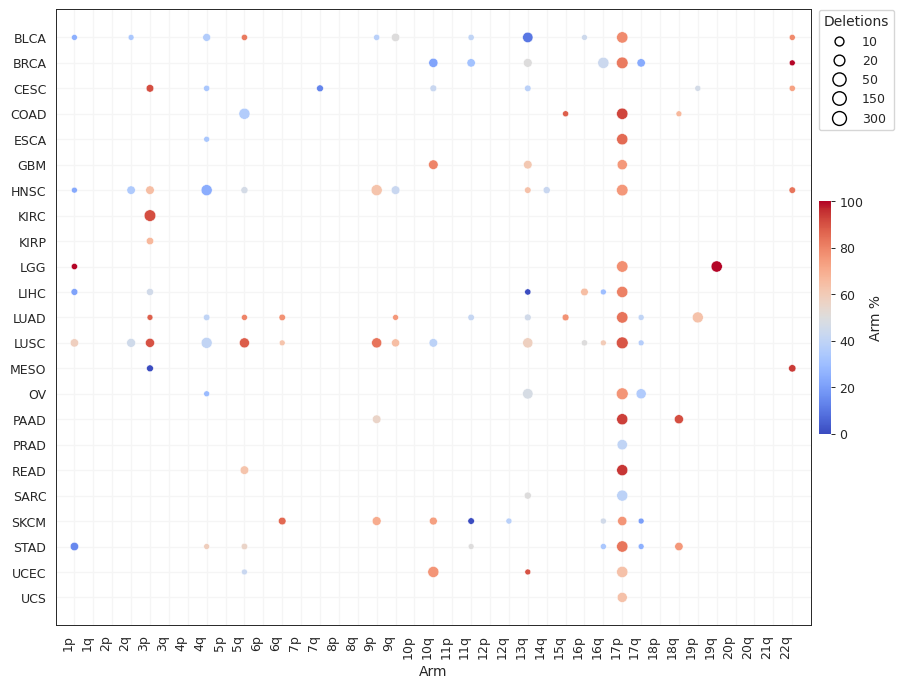

In [12]:
config_rcparams()

plt.figure(figsize=(10,8))


data = pd.merge(mut_tsg,mut_tsg_tumorcounts,on=['CODE','arm'])
data['size'] = size_scale(data['tot'])

x_order = ['1p','1q','2p','2q','3p','3q','4p','4q','5p','5q','6p','6q','7p','7q','8p','8q','9p','9q','10p','10q','11p','11q','12p','12q','13q','14q','15q','16p','16q','17p','17q','18p','18q','19p','19q','20p','20q','21q','22q']
data['arm'] = pd.Categorical(data['arm'], categories=x_order, ordered=True)
data = data.sort_values('arm')
data = data.sort_values('CODE')
data = data[data.tot>=10]

def custom_size_scaler(n):
    if n <= 10:
        return 1 + (n - 5) / (10 - 5) * (40 - 0)
    elif n <= 20:
        return 40 + (n - 11) / (20 - 11) * (60 - 40)
    elif n <= 50:
        return 60 + (n - 21) / (50 - 21) * (90 - 60)
    elif n <= 275:
        return 90 + (n - 51) / (275 - 51) * (100 - 90)
    else:
        return 100
    
data['size'] = data['tot'].apply(custom_size_scaler)

ax = sns.scatterplot(data=data, x='arm',y='CODE',size='size',hue='armpercent', palette='coolwarm', legend=False)
ax.grid(True,color='whitesmoke')

# legend 1
norm = plt.Normalize(data['armpercent'].min(), data['armpercent'].max())
sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.015, pad=0.01)
cbar.set_label("Arm %", fontsize=10)
cbar.ax.tick_params(labelsize=9)  
cbar.outline.set_visible(False)  
cbar.ax.set_frame_on(False)

# legend 2
legend_sample_sizes = [10, 20, 50, 150, 300]
legend_handles = [
    Line2D(
        [], [], 
        marker='o', linestyle='None',
        markersize=np.sqrt(custom_size_scaler(s)),  
        markerfacecolor='none', markeredgecolor='black',
        label=f'{s}'
    )
    for s in legend_sample_sizes
]

plt.legend(
    handles=legend_handles, 
    title='Deletions', fontsize=9, title_fontsize=10, bbox_to_anchor=(7, 1.85))

ax.set_xticks(np.arange(len(x_order)))
ax.set_xticklabels(x_order, rotation=90, ha='right', fontsize=9)

y_labels = data['CODE'].unique()
ax.set_yticks(np.arange(len(y_labels)))
ax.set_yticklabels(y_labels, fontsize=9)
ax.set_xlim(-1,39)

ax.set_xlabel('Arm', fontsize=10)
ax.set_ylabel(None)

plt.show()

---